In [9]:
import pandas as pd

# Read the two files
df1 = pd.read_csv("claims_staged_cmu_2_2.csv")
df2 = pd.read_csv("claims_staged_cmu_1_2.csv")

# Combine them
combined_df = pd.concat([df1, df2], ignore_index=True)


In [11]:
combined_df.shape[0]

2517387

In [13]:
combined_df

,PRI_DIAG_CD,ADM_DIAG_CD,DIAG_CD_001,DIAG_CD_002,DIAG_CD_003,HCPCS,DRG,Med_Cost_Category,NDC_CD,DRUG_NM,...,provider_number,ROUTE DESCRIPTION,STRENGTH DESCRIPTION,PROC_DESC,DIAG_DESC,DRG_DESC,ADM_DIAG_DESC,DIAG_001_DIAG_DESC,DIAG_002_DIAG_DESC,DIAG_003_DIAG_DESC
0,C50912,NaN,Z170,NaN,NaN,85025,NaN,OP Path/Lab,NaN,NaN,...,2015.0,NaN,NaN,Complete cbc w/auto diff wbc,Malignant neoplasm of unspecified site of left...,NaN,NaN,Estrogen receptor positive status [ER+],NaN,NaN
1,C50912,NaN,Z170,NaN,NaN,81432,NaN,Prof Specialist Procedures,NaN,NaN,...,8139.0,NaN,NaN,Hrdtry brst ca-rlatd dsordrs,Malignant neoplasm of unspecified site of left...,NaN,NaN,Estrogen receptor positive status [ER+],NaN,NaN
2,Z01818,NaN,NaN,NaN,NaN,93010,NaN,Prof Specialist Procedures,NaN,NaN,...,NaN,NaN,NaN,Electrocardiogram report,Encounter for other preprocedural examination,NaN,NaN,NaN,NaN,NaN
3,E876,E876,J189,I4710,K521,NaN,640.0,IP Medical,NaN,NaN,...,2015.0,NaN,NaN,NaN,Hypokalemia,"Misc Disorders of Nutrition, Metabolism, Fluid...",Hypokalemia,"Pneumonia, unspecified organism",NaN,Toxic gastroenteritis and colitis
4,E876,NaN,C50919,D72829,N189,99285,NaN,Prof Invisible Prov Procedures,NaN,NaN,...,NaN,NaN,NaN,Emergency dept visit,Hypokalemia,NaN,NaN,Malignant neoplasm of unsp site of unspecified...,"Elevated white blood cell count, unspecified","Chronic kidney disease, unspecified"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2517382,N390,NaN,NaN,NaN,NaN,81001,NaN,OP Path/Lab,NaN,NaN,...,2015.0,NaN,NaN,Urinalysis auto w/scope,"Urinary tract infection, site not specified",NaN,NaN,NaN,NaN,NaN
2517383,C50912,NaN,Z170,NaN,NaN,85730,NaN,OP Path/Lab,NaN,NaN,...,2015.0,NaN,NaN,Thromboplastin time partial,Malignant neoplasm of unspecified site of left...,NaN,NaN,Estrogen receptor positive status [ER+],NaN,NaN
2517384,C50912,NaN,Z170,NaN,NaN,80053,NaN,OP Path/Lab,NaN,NaN,...,2015.0,NaN,NaN,Comprehen metabolic panel,Malignant neoplasm of unspecified site of left...,NaN,NaN,Estrogen receptor positive status [ER+],NaN,NaN
2517385,C50912,NaN,Z170,NaN,NaN,85610,NaN,OP Path/Lab,NaN,NaN,...,2015.0,NaN,NaN,Prothrombin time,Malignant neoplasm of unspecified site of left...,NaN,NaN,Estrogen receptor positive status [ER+],NaN,NaN


In [15]:
missing_percent = combined_df.isnull().mean() * 100
print(missing_percent)
# The provider column has 34.50% of the rows with null values

PRI_DIAG_CD               14.067960
ADM_DIAG_CD               99.608642
DIAG_CD_001               40.634038
DIAG_CD_002               55.956712
DIAG_CD_003               66.030928
HCPCS                     20.763077
DRG                       99.805711
Med_Cost_Category          0.000000
NDC_CD                    69.652739
DRUG_NM                   69.611983
C_UTIL_CT                  0.000000
c_allowed                  0.000000
days_since_earliest_dt     0.000000
member_number              0.000000
provider_number           34.493266
ROUTE DESCRIPTION         70.944992
STRENGTH DESCRIPTION      70.944992
PROC_DESC                 22.932668
DIAG_DESC                 15.287002
DRG_DESC                  99.806863
ADM_DIAG_DESC             99.614521
DIAG_001_DIAG_DESC        41.624272
DIAG_002_DIAG_DESC        56.914372
DIAG_003_DIAG_DESC        66.737335
dtype: float64


In [17]:
combined_df["provider_number"].nunique()

8220

In [19]:
provider_patient_counts = (
    combined_df.groupby("provider_number")["member_number"]
    .nunique()
    .reset_index(name="patient_count")
    .sort_values(by="patient_count", ascending=False)
)

provider_patient_counts.head(20)

,provider_number,patient_count
2243,2244.0,2709
2235,2236.0,2430
2112,2113.0,1141
2280,2281.0,984
7067,7068.0,920
7530,7531.0,819
8093,8094.0,780
2282,2283.0,737
6940,6941.0,713
7150,7151.0,681


In [21]:
provider_cost = (
    combined_df.groupby("provider_number")["c_allowed"]
    .sum()
    .reset_index(name="total_allowed_cost")
    .sort_values(by="total_allowed_cost", ascending=False)
)

provider_cost.head(20)

,provider_number,total_allowed_cost
2243,2244.0,1.932457e+08
2235,2236.0,7.368938e+07
2222,2223.0,3.223756e+07
2280,2281.0,1.699849e+07
2282,2283.0,1.551887e+07
2253,2254.0,9.208773e+06
2014,2015.0,8.187957e+06
2277,2278.0,6.735053e+06
8093,8094.0,6.094993e+06
2227,2228.0,5.998772e+06


In [23]:
provider_cost_1 = (
    combined_df.groupby("provider_number")["c_allowed"]
    .mean()
    .reset_index(name="mean_allowed_cost")
    .sort_values(by="mean_allowed_cost", ascending=False)
)

provider_cost_1.head(20)

,provider_number,mean_allowed_cost
1961,1962.0,245411.472426
2409,2410.0,105380.150563
7856,7857.0,86704.145410
7855,7856.0,48778.853333
7359,7360.0,44768.340000
2250,2251.0,37983.091638
2304,2305.0,35571.121335
2406,2407.0,34069.955000
2084,2085.0,33569.590000
2080,2081.0,30001.452483


In [25]:
provider_util = (
    combined_df.groupby("provider_number")["C_UTIL_CT"]
    .sum()
    .reset_index(name="sum_util")
    .sort_values(by="sum_util", ascending=False)
)

provider_util.head(20)

,provider_number,sum_util
2243,2244.0,89110.600391
2235,2236.0,48715.093891
2112,2113.0,22259.365209
2222,2223.0,21552.411346
2280,2281.0,20916.600428
2405,2406.0,19159.134908
2282,2283.0,16848.487295
2227,2228.0,12481.346066
7816,7817.0,11784.028812
2265,2266.0,10176.448369


In [27]:
df3 = pd.read_csv("staging_dataset.csv")

In [29]:
combined_df_1 = combined_df.merge(df3, on="member_number", how="left")

In [37]:
# Copied from Joanna's code (Thank you Joanna!!)
combined_df_1['ICD10_group'] = combined_df_1['ICD10_CODE'].str[:3]
detailed_cancer_map = {
    "C50": "breast",
    "C34": "lung",
    "C18": "colon",
    "C19": "rectal",      # rectosigmoid
    "C20": "rectal",      # rectum
    "C21": "anal"         # anus (or keep as colorectal)
}

'''
treatments for colon and rectal cancers are different, so we create a new column for detailed cancer type
'''

combined_df_1['detailed_cancer_type'] = combined_df_1['ICD10_group'].map(detailed_cancer_map)

# creating a new column for cancer type, C18, C19, C20, C21 are all colorectal
broad_cancer_map = {
    "C50": "breast",
    "C34": "lung",
    "C18": "colorectal",
    "C19": "colorectal",
    "C20": "colorectal",
    "C21": "colorectal"
}
combined_df_1['cancer_type'] = combined_df_1['ICD10_group'].map(broad_cancer_map)

In [39]:
# Copied from Joanna's code (Thank you Joanna!!)
combined_df_1["FINAL_STAGE"] = (
    combined_df_1["CLINICAL_STAGE_GROUP"]
    .combine_first(combined_df_1["PATHOLOGIC_STAGE_GROUP"])
)
Simple_stage_map = {
    "Stage 0": "Stage 0", #
    "Stage I": "Stage 1", #
    "Stage IA": "Stage 1", #
    "Stage IA1": "Stage 1", #
    "Stage IA2": "Stage 1", #
    "Stage IA3": "Stage 1", #
    "Stage IB": "Stage 1", #
    "Stage II": "Stage 2", #
    "Stage IIA": "Stage 2", #
    "Stage IIB": "Stage 2", #
    "Stage IIC": "Stage 2", #
    "Stage IIIA": "Stage 3", #
    "Stage IIIB": "Stage 3", #
    "Stage IIIC": "Stage 3", #
    "Stage IV": "Stage 4", #
    "Stage IVA": "Stage 4", #
    "Stage IVB": "Stage 4", #
    "Stage IVC": "Stage 4", #
    "No Stage Recommended": "No Stage",
    "Stage Unknown": "No Stage",
    "Occult carcinoma": "No Stage",   
    
}

# add a column for simple stage info
combined_df_1['simple_stage'] = combined_df_1['FINAL_STAGE'].map(Simple_stage_map)
combined_df_1.head()

,PRI_DIAG_CD,ADM_DIAG_CD,DIAG_CD_001,DIAG_CD_002,DIAG_CD_003,HCPCS,DRG,Med_Cost_Category,NDC_CD,DRUG_NM,...,ICD10_CODE,MOST_RECENT_PATH_STAGE_DT,MOST_RECENT_CLINICAL_STAGE_DT,PATHOLOGIC_STAGE_GROUP,CLINICAL_STAGE_GROUP,FINAL_STAGE,simple_stage,ICD10_group,detailed_cancer_type,cancer_type
0,C50912,NaN,Z170,NaN,NaN,85025,NaN,OP Path/Lab,NaN,NaN,...,C50.912,NaN,153.0,NaN,Stage IIB,Stage IIB,Stage 2,C50,breast,breast
1,C50912,NaN,Z170,NaN,NaN,81432,NaN,Prof Specialist Procedures,NaN,NaN,...,C50.912,NaN,153.0,NaN,Stage IIB,Stage IIB,Stage 2,C50,breast,breast
2,Z01818,NaN,NaN,NaN,NaN,93010,NaN,Prof Specialist Procedures,NaN,NaN,...,C50.912,NaN,153.0,NaN,Stage IIB,Stage IIB,Stage 2,C50,breast,breast
3,E876,E876,J189,I4710,K521,NaN,640.0,IP Medical,NaN,NaN,...,C50.912,NaN,153.0,NaN,Stage IIB,Stage IIB,Stage 2,C50,breast,breast
4,E876,NaN,C50919,D72829,N189,99285,NaN,Prof Invisible Prov Procedures,NaN,NaN,...,C50.912,NaN,153.0,NaN,Stage IIB,Stage IIB,Stage 2,C50,breast,breast


In [41]:
provider_cancer_counts = (
    combined_df_1.groupby(["provider_number", "cancer_type"])["member_number"]
    .nunique()
    .reset_index(name="patient_count")
)

In [43]:
pivot_table = provider_cancer_counts.pivot(
    index="provider_number",
    columns="cancer_type",
    values="patient_count"
).fillna(0)

In [45]:
top_providers = pivot_table.sum(axis=1).sort_values(ascending=False).head(10)
pivot_top = pivot_table.loc[top_providers.index]

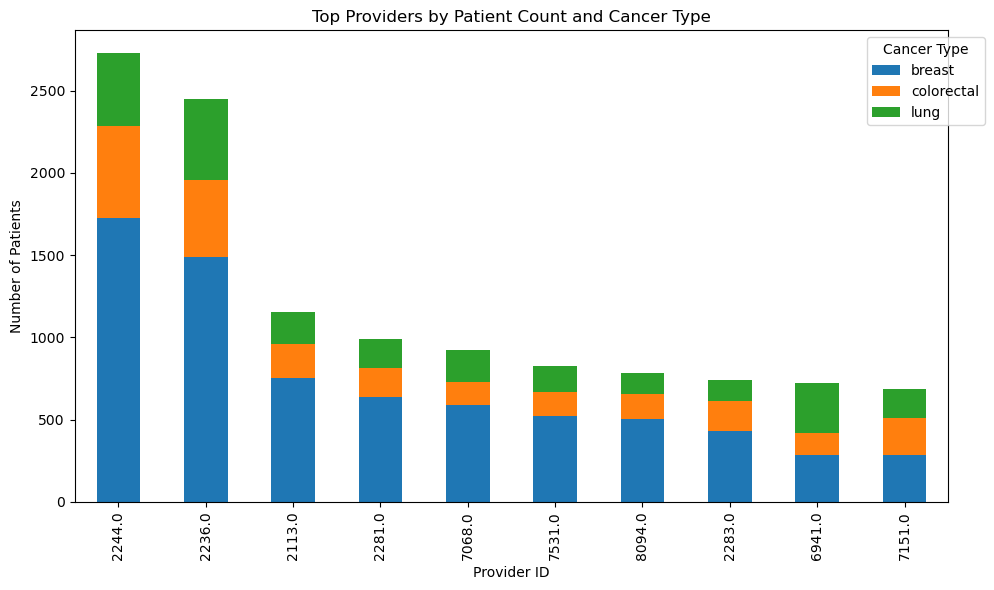

In [47]:
import matplotlib.pyplot as plt

pivot_top.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Provider ID")
plt.ylabel("Number of Patients")
plt.title("Top Providers by Patient Count and Cancer Type")
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

In [49]:
# Provider Specialization Analysis: Looking at whether providers focus on one cancer type of treat multiple cancer types 
provider_cancer_counts = combined_df_1.groupby("provider_number")["cancer_type"].nunique()
provider_distribution = provider_cancer_counts.value_counts().sort_index()
total_cancers = combined_df_1["cancer_type"].nunique()

one_cancer = (provider_cancer_counts == 1).sum()
two_cancers = (provider_cancer_counts == 2).sum()
all_cancers = (provider_cancer_counts == total_cancers).sum()

print("Providers treating 1 cancer:", one_cancer)
print("Providers treating 2 cancers:", two_cancers)
print("Providers treating all cancers:", all_cancers)

Providers treating 1 cancer: 3900
Providers treating 2 cancers: 2010
Providers treating all cancers: 2310


  provider_group   mean_cost
0       1 cancer  212.659769
1      2 cancers  146.073266
2    all cancers  324.549980


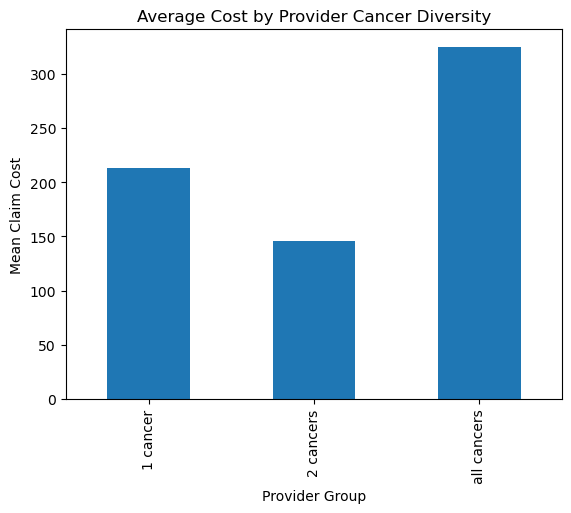

In [105]:
# Mean Cost Based on whether the providers are treating one vs. multiple cancers? 
provider_groups = provider_cancer_counts.apply(
    lambda x: "1 cancer" if x == 1 
    else "2 cancers" if x == 2 
    else "all cancers" if x == total_cancers 
    else "other"
)

combined_df_1["provider_group"] = combined_df_1["provider_number"].map(provider_groups)

mean_cost = (
    combined_df_1.groupby("provider_group")["c_allowed"]
    .mean()
    .reset_index(name="mean_cost")
)

print(mean_cost)

mean_cost.set_index("provider_group")["mean_cost"].plot(kind="bar")

plt.ylabel("Mean Claim Cost")
plt.xlabel("Provider Group")
plt.title("Average Cost by Provider Cancer Diversity")
plt.show()

In [71]:
provider_cancers = (combined_df_1.groupby("provider_number")["cancer_type"].unique())
provider_cancers = provider_cancers.apply(lambda x: tuple(sorted(x)))
combo_counts = provider_cancers.value_counts()

one_cancer = combo_counts[[len(c) == 1 for c in combo_counts.index]]
print("Providers treating exactly ONE cancer type:")
print(one_cancer)
print("\n")

two_cancers = combo_counts[[len(c) == 2 for c in combo_counts.index]]
print("Providers treating exactly TWO cancer types:")
print(two_cancers)
print("\n")

Providers treating exactly ONE cancer type:
cancer_type
(breast,)        2608
(colorectal,)     701
(lung,)           591
Name: count, dtype: int64


Providers treating exactly TWO cancer types:
cancer_type
(breast, colorectal)    1037
(breast, lung)           807
(colorectal, lung)       166
Name: count, dtype: int64




In [93]:
provider_cancer_cost = (
    combined_df_1.groupby(["provider_number", "cancer_type"])["c_allowed"]
    .mean()
    .reset_index()
)

In [95]:
pivot_cost = provider_cancer_cost.pivot(
    index="provider_number",
    columns="cancer_type",
    values="c_allowed"
).fillna(0)

In [97]:
top_providers = (
    combined_df_1.groupby("provider_number")["c_allowed"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

pivot_top = pivot_cost.loc[top_providers.index]

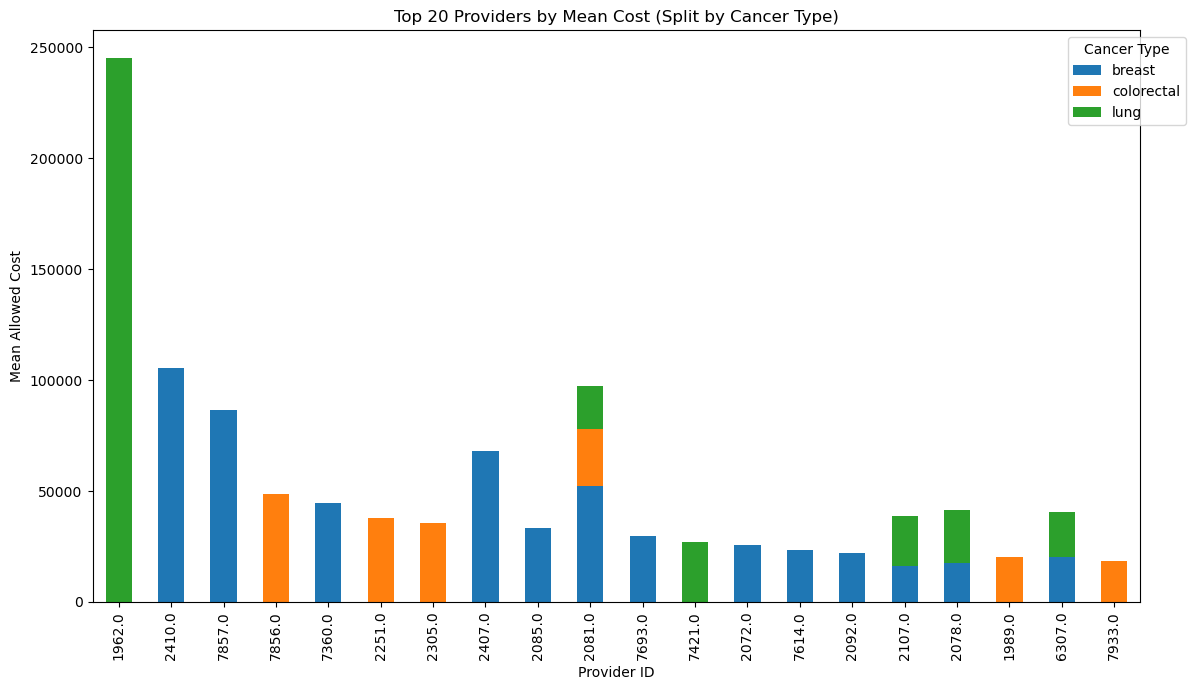

In [99]:
pivot_top.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.xlabel("Provider ID")
plt.ylabel("Mean Allowed Cost")
plt.title("Top 20 Providers by Mean Cost (Split by Cancer Type)")
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

In [113]:
provider_cancer_util = (
    combined_df_1.groupby(["provider_number", "cancer_type"])["C_UTIL_CT"]
    .sum()
    .reset_index()
)

In [115]:
pivot_util = provider_cancer_util.pivot(
    index="provider_number",
    columns="cancer_type",
    values="C_UTIL_CT"
).fillna(0)

In [121]:
top_providers = (
    combined_df_1.groupby("provider_number")["C_UTIL_CT"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

pivot_top_util = pivot_util.loc[top_providers.index]

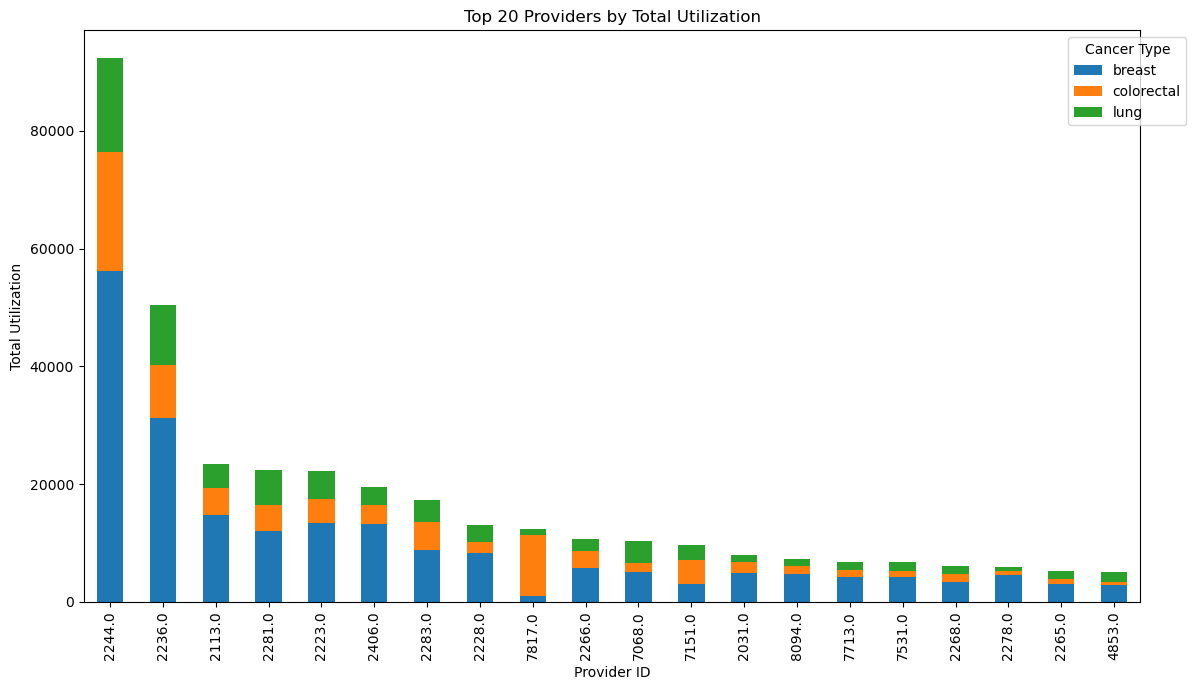

In [125]:
pivot_top_util.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.xlabel("Provider ID")
plt.ylabel("Total Utilization")
plt.title("Top 20 Providers by Total Utilization")
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()